In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # Fixed: Changed 'PCAa' to 'PCA'
import umap
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_excel('OCT_2025_RBS_FULL_DATA_SET.XLSX')
df.head()

,ROUTE_NAME,ROUTE_NUMBER,SERVICE_PERIOD,SERVICE_CODE,DIRECTION_NAME,BRANCH,TRIP_TIME,SORT_ORDER,STOP_ID,MAIN_CROSS_STREET,...,Stop_ID_Num,STOP_DISPLAY,Additional_Notes,PATTERN_KEY,BLOCK,TOTAL_SORT,SORT_SP,ROUTE_REV,SERVICE_CODE2,Stop_ID_REV
0,22: Palo Alto - Eastridge,22.0,Saturday,Frequent,EAST,[22]Palo Alto > Eastridge,00:35:00,680.0,1.0,SANTA CLARA TRANSIT CENTER,...,60001.0,1.0,NaN,EB04,3507.0,STATS,2.0,22:,Local,60001:
1,22: Palo Alto - Eastridge,22.0,Saturday,Frequent,EAST,[22]Palo Alto > Eastridge,01:57:00,680.0,1.0,SANTA CLARA TRANSIT CENTER,...,60001.0,1.0,NaN,EB04,2707.0,STATS,2.0,22:,Local,60001:
2,22: Palo Alto - Eastridge,22.0,Saturday,Frequent,EAST,[22]Palo Alto > Eastridge,04:32:00,680.0,1.0,SANTA CLARA TRANSIT CENTER,...,60001.0,1.0,NaN,EB04,2207.0,STATS,2.0,22:,Local,60001:
3,22: Palo Alto - Eastridge,22.0,Saturday,Frequent,EAST,[22]Palo Alto > Eastridge,04:58:00,680.0,1.0,SANTA CLARA TRANSIT CENTER,...,60001.0,1.0,NaN,EB04,2407.0,STATS,2.0,22:,Local,60001:
4,22: Palo Alto - Eastridge,22.0,Saturday,Frequent,EAST,[22]Palo Alto > Eastridge,05:23:00,680.0,1.0,SANTA CLARA TRANSIT CENTER,...,60001.0,1.0,NaN,EB04,2607.0,STATS,2.0,22:,Local,60001:


In [3]:

numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
numeric_cols.remove('BOARDINGS')

X = df[numeric_cols].copy()
y = df['BOARDINGS'].copy()


X = X.dropna()
y = y[X.index]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (382714, 17)
Target shape: (382714,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean():.6f}")
print(f"Std (should be ~1): {X_scaled.std():.6f}")

Scaled data shape: (382714, 17)
Mean (should be ~0): -0.000000
Std (should be ~1): 1.000000


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

print(f"PCA shape: {pca_result.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

PCA shape: (382714, 2)
Explained variance ratio: [0.33344054 0.17635105]
Total variance explained: 0.5098


In [6]:
import plotly.express as px

# Create dataframe for plotting
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'BOARDINGS': y.values
})


pca_df_sample = pca_df.sample(n=5000, random_state=42)

fig = px.scatter(pca_df_sample, x='PC1', y='PC2', color='BOARDINGS',
                title='PCA: Feature Space Reduction',
                labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', 
                        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'})
fig.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate Predictions
y_pred = model.predict(X_test)

# Calculate Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R² Score: 0.6780
RMSE: 6.5411
MAE: 3.2994


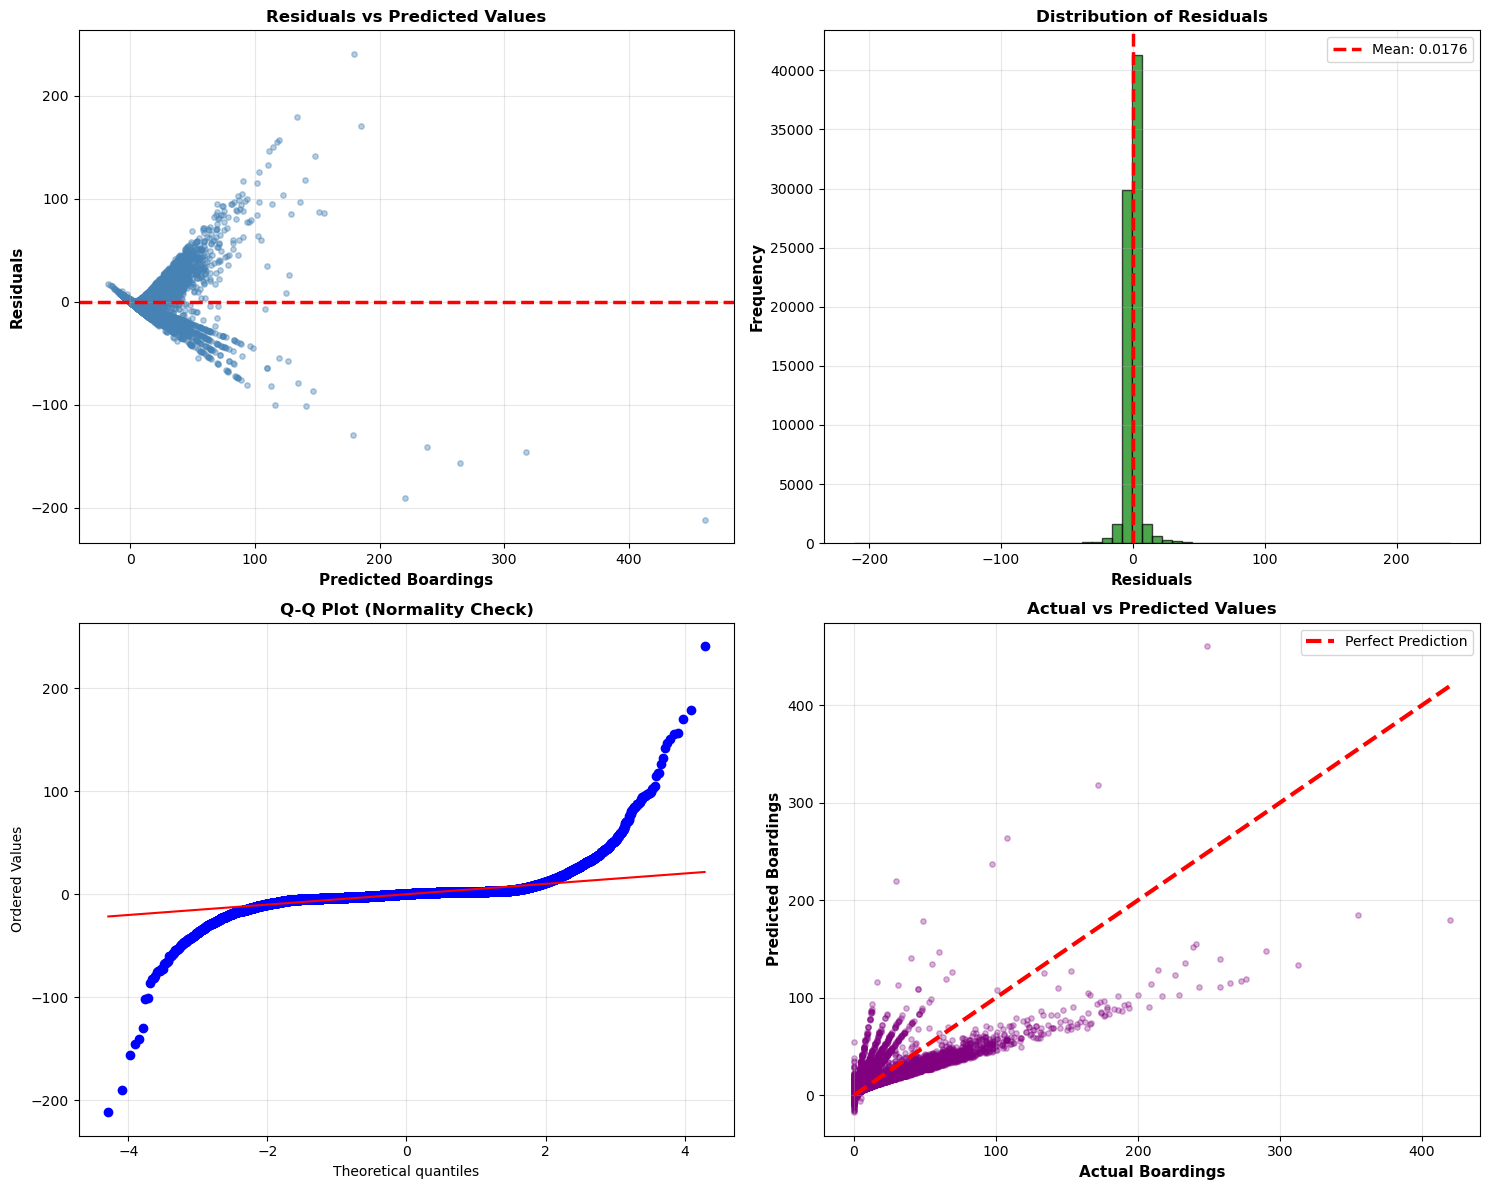

✓ Residual Analysis Complete


In [8]:
residuals = y_test - y_pred
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2.5)
axes[0, 0].set_xlabel('Predicted Boardings', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(residuals, bins=60, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {residuals.mean():.4f}')
axes[0, 1].set_xlabel('Residuals', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y_test, y_pred, alpha=0.3, s=15, color='purple')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Boardings', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Predicted Boardings', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Residual Analysis Complete")

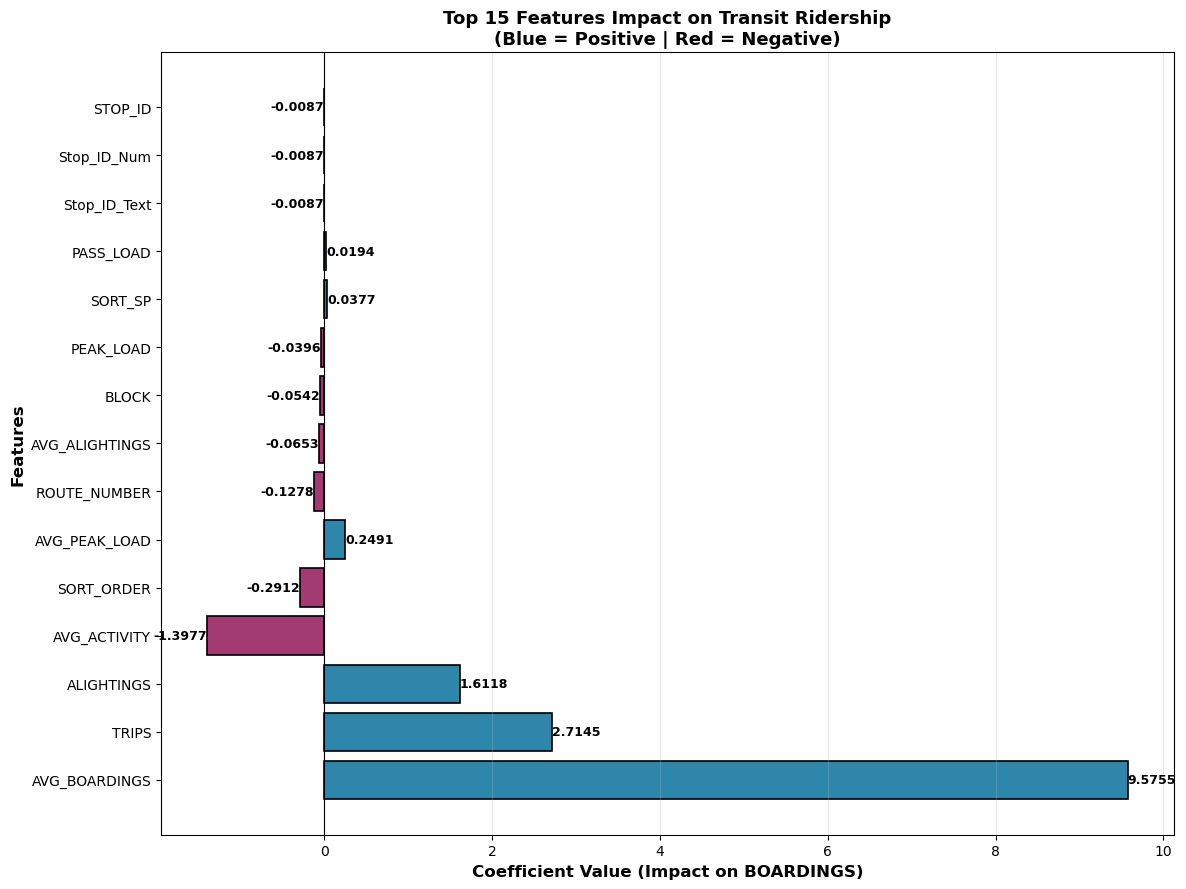


=== TOP 10 FEATURES AFFECTING TRANSIT BOARDINGS ===
       Feature  Coefficient  Abs_Coefficient
 AVG_BOARDINGS     9.575522         9.575522
         TRIPS     2.714481         2.714481
    ALIGHTINGS     1.611758         1.611758
  AVG_ACTIVITY    -1.397680         1.397680
    SORT_ORDER    -0.291190         0.291190
 AVG_PEAK_LOAD     0.249127         0.249127
  ROUTE_NUMBER    -0.127804         0.127804
AVG_ALIGHTINGS    -0.065309         0.065309
         BLOCK    -0.054205         0.054205
     PEAK_LOAD    -0.039628         0.039628


In [9]:
feature_importance = pd.DataFrame({
    'Feature': numeric_cols,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))

colors = ['#2E86AB' if x > 0 else '#A23B72' for x in feature_importance['Coefficient'][:15]]

bars = ax.barh(feature_importance['Feature'][:15], feature_importance['Coefficient'][:15], color=colors, edgecolor='black', linewidth=1.2)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.4f}', ha='left' if width > 0 else 'right', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Coefficient Value (Impact on BOARDINGS)', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features Impact on Transit Ridership\n(Blue = Positive | Red = Negative)', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n=== TOP 10 FEATURES AFFECTING TRANSIT BOARDINGS ===")
print(feature_importance.head(10).to_string(index=False))

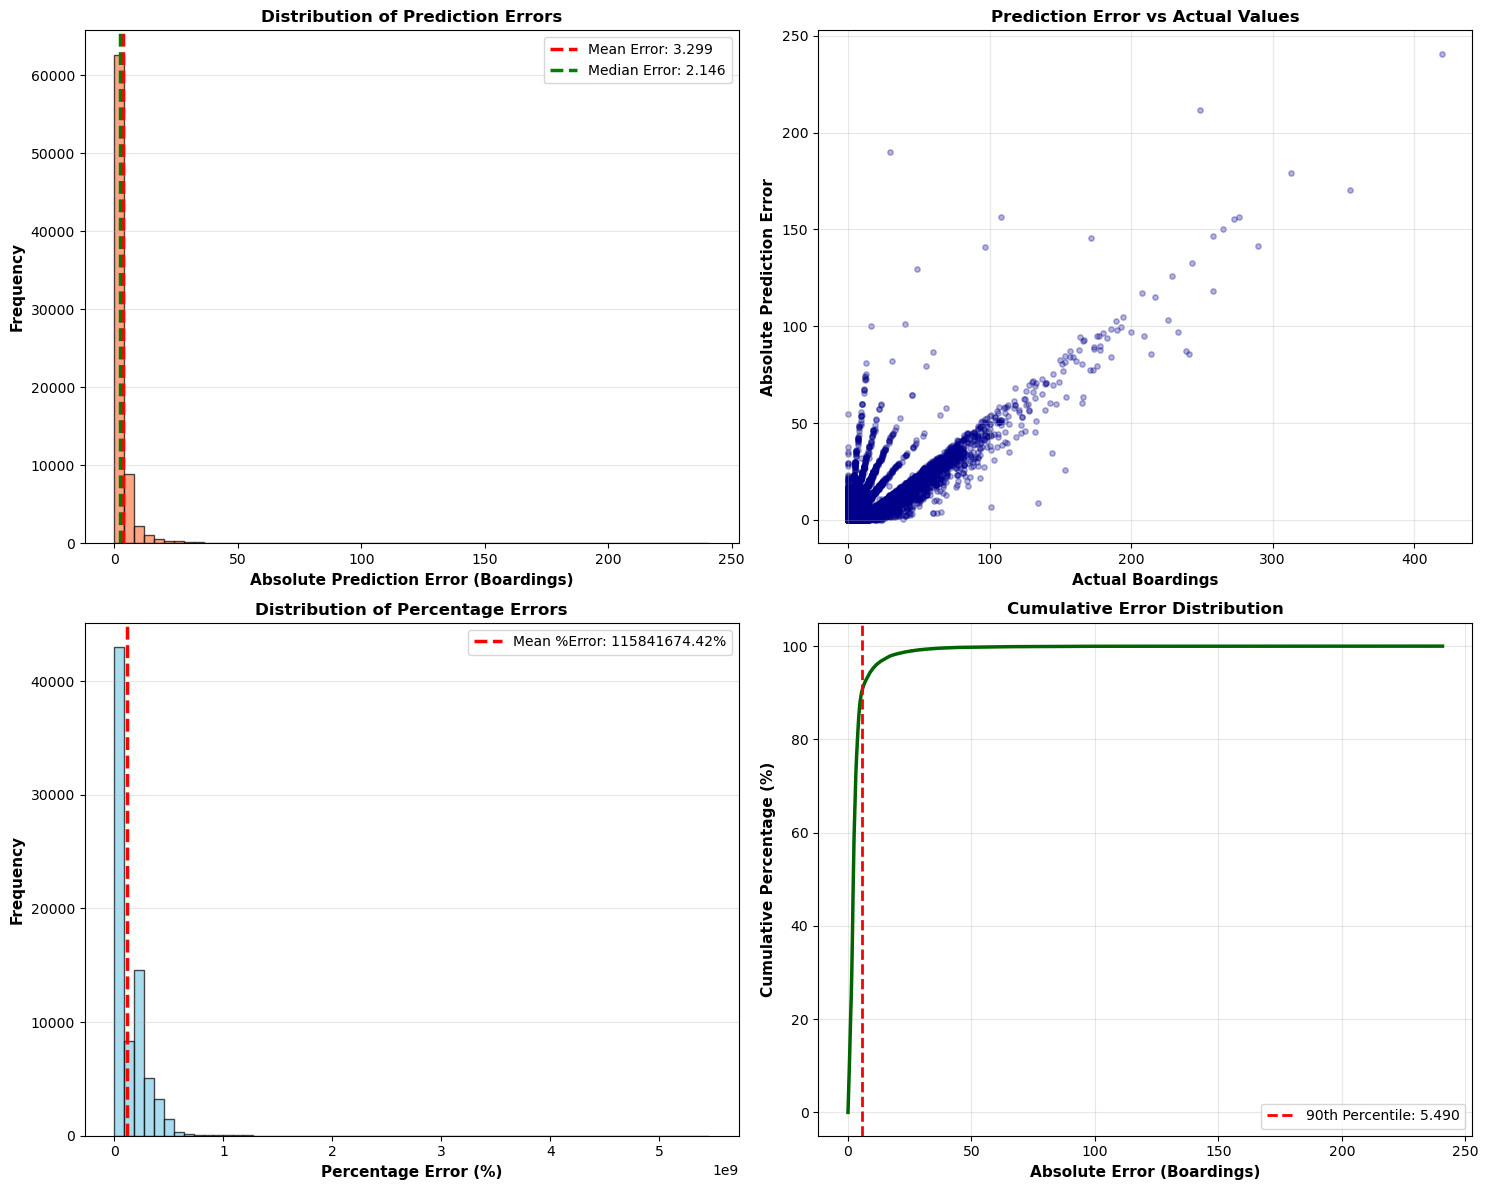


TRANSIT RIDERSHIP MODEL - PERFORMANCE SUMMARY

R² Score: 0.6780
RMSE: 6.5411 boardings
MAE: 3.2994 boardings


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

errors = np.abs(y_test - y_pred)

axes[0, 0].hist(errors, bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].axvline(errors.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean Error: {errors.mean():.3f}')
axes[0, 0].axvline(np.median(errors), color='green', linestyle='--', linewidth=2.5, label=f'Median Error: {np.median(errors):.3f}')
axes[0, 0].set_xlabel('Absolute Prediction Error (Boardings)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].scatter(y_test, errors, alpha=0.3, s=15, color='darkblue')
axes[0, 1].set_xlabel('Actual Boardings', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Absolute Prediction Error', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Prediction Error vs Actual Values', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Fixed: Filter out invalid percentage errors
percent_errors = np.abs((y_test.values - y_pred) / (y_test.values + 1e-6)) * 100
percent_errors = percent_errors[np.isfinite(percent_errors)]
axes[1, 0].hist(percent_errors, bins=60, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].axvline(percent_errors.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean %Error: {percent_errors.mean():.2f}%')
axes[1, 0].set_xlabel('Percentage Error (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Distribution of Percentage Errors', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

sorted_errors = np.sort(errors)
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
axes[1, 1].plot(sorted_errors, cumulative, linewidth=2.5, color='darkgreen')
axes[1, 1].axvline(np.percentile(errors, 90), color='red', linestyle='--', linewidth=2, label=f'90th Percentile: {np.percentile(errors, 90):.3f}')
axes[1, 1].set_xlabel('Absolute Error (Boardings)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Cumulative Percentage (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Cumulative Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("TRANSIT RIDERSHIP MODEL - PERFORMANCE SUMMARY")
print("="*70)
print(f"\nR² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f} boardings")
print(f"MAE: {mae:.4f} boardings")
print("="*70)